### Pós-graduação em Ciência de Dados e Machine Learning

#### Disciplina: **Introdução a Redes Neurais**

#### Projeto Final para disciplina Introdução a Redes Neurais

<BR>
    

#### Nome dos integrantes:  
#### RA: Charles Bezerra - 52400351
#### RA: Gabriel Xavier - 52400192
#### RA: Jheferson Warley - 52400071
#### RA: Paulo Lima Machado - 52400245


**Descrição do Trabalho:**

O projeto final será feito em grupos de até 4 pessoas. Os alunos deverão escolher uma base de dados que não foi tratada no decorrer da matéria e criar um algoritmo de deep learning para solucionar o problema. Lembrem-se de explicar o que está sendo desenvolvido no decorrer do código. A avaliação levará em conta o grau de complexidade do problema que escolherem. Bases que representam problemas reais são preferíveis. 
 
Utilizem artigos científicos como meio para criar a arquitetura da rede neural. Façam um resumo do problema que o autor do paper tratou, bem como sobre as técnicas e teorias apontadas. Recorram somente as matérias a partir de redes Convolucionais. 

Soluções que só fazem uso exclusivo das MLP serão desconsideradas.

# 💻 Classificação de Grãos de Café com CNN

## A Jornada da Classificação de Grãos de Café: Um Projeto com DenseNet121

Este trabalho tomou por base o artigo disponível em: https://ieeexplore.ieee.org/document/10674676

A base de dados utilizada foi obtida em: https://www.kaggle.com/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224

Imagine um agricultor em uma fazenda de café, olhando para uma pilha de grãos e tentando decidir quais estão prontos para a colheita. Dark, Green, Light ou Medium? Essa escolha define a qualidade do café que chegará à xícara – mas é um processo demorado e sujeito a erros humanos. Foi pensando nisso que iniciamos nosso projeto: **classificar grãos de café automaticamente usando visão computacional e aprendizado profundo (Deep Learning)**.

Para isso foi utilizado um conjunto de 1600 imagens de grãos de café divididas em quatro classes, e aplicados modelos de redes neurais convolucionais (CNNs). Deste conjunto, separamos 1200 para treinamento e 400 para testes.

## Selecionamos 2 modelos de redes neurais convolucionais:

### DenseNet121

Possui conexões densas que capturam detalhes visuais, como as texturas e cores dos grãos, de forma eficiente, com apenas ~8 milhões de parâmetros, bem menos que os ~25 milhões do ResNet50V2, por exemplo. 

### Xception

Uma interpretação dos módulos Inception em redes neurais convolucionais como sendo uma etapa intermediária entre a convolução regular e a operação de convolução separável em profundidade (uma convolução em profundidade seguida por uma convolução pontual). Uma proposta de arquitetura de rede neural convolucional profunda inspirada no Inception, onde os módulos do Inception foram substituídos por convoluções separáveis em profundidade.


# 📚 Importação das Bibliotecas

In [1]:
# !pip install tensorflow

In [2]:
#Importação das Bibliotecas
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
import random 
from IPython.display import display, Markdown
# -----
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
# ------
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

2025-04-29 15:25:41.885668: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 15:25:41.888429: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 15:25:41.895547: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745951141.906953    4645 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745951141.910310    4645 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745951141.920262    4645 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
print(tf.__version__)

2.19.0


In [4]:
df = pd.read_csv('archive/Coffee Bean.csv')

In [5]:
df.head(5)

,class index,filepaths,labels,data set
0,0,train/Dark/dark (1).png,Dark,train
1,0,train/Dark/dark (10).png,Dark,train
2,0,train/Dark/dark (100).png,Dark,train
3,0,train/Dark/dark (101).png,Dark,train
4,0,train/Dark/dark (102).png,Dark,train


In [6]:
df.tail(5)

,class index,filepaths,labels,data set
1595,3,test/Medium/medium (95).png,Medium,test
1596,3,test/Medium/medium (96).png,Medium,test
1597,3,test/Medium/medium (97).png,Medium,test
1598,3,test/Medium/medium (98).png,Medium,test
1599,3,test/Medium/medium (99).png,Medium,test


In [7]:
# Varre dataframe df e carrega as imagens definidas em "filepaths" em um array
paths = df['filepaths'].tolist()

In [8]:
imagens = []

for path in paths:
    try:
        img = Image.open('archive/'+path).convert('RGB')  
        img_array = np.array(img)
        imagens.append(img_array)
    except Exception as e:
        print(f"Erro ao carregar {path}: {e}")

In [9]:
# Converte a lista de arrays para um array NumPy (se todas forem do mesmo tamanho)
imagens_array = np.stack(imagens)

In [10]:
imagens_array.shape

(1600, 224, 224, 3)

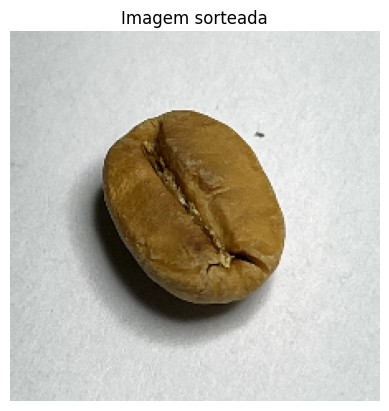

In [11]:
# Sorteia e mostra uma das imagens
imagem_sorteada = random.choice(imagens)

plt.imshow(imagem_sorteada)
plt.axis('off')  # remove os eixos
plt.title("Imagem sorteada")
plt.show()

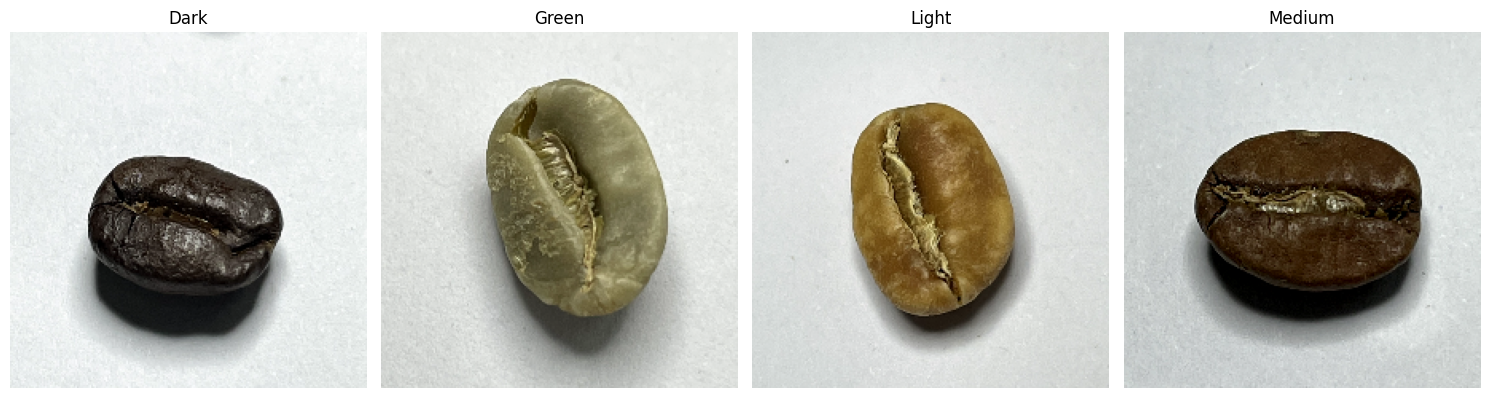

In [12]:
# Tipos de café 
classes = ['Dark', 'Green', 'Light', 'Medium']

# Criar uma figura com subplots
plt.figure(figsize=(15, 7))

# Iterar sobre as classes e exibir uma imagem aleatória de cada
for i, class_name in enumerate(classes, 1):

    class_df = df[df['labels'] == class_name]

    random_index = random.choice(class_df.index)
    
    
    img = imagens_array[random_index]
    

    plt.subplot(1, 4, i)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
train_dir = "archive/train"
test_dir = "archive/test"

# 🧪 Preparação dos Dados
Utilizamos a classe `ImageDataGenerator` para aplicar **data augmentation** nas imagens de treino.<br>
Esse processo gera variações artificiais nas imagens, como rotações, deslocamentos e espelhamentos,
aumentando a robustez do modelo.

In [14]:
# Configurar ImageDataGenerator com aumento de dados
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

### 📁 Carregamento das Imagens
As imagens são carregadas a partir de diretórios organizados por classe.<br>
Cada subpasta representa uma categoria de maturação do grão de café.

In [15]:
# Carregar dados em lotes
train_data = train_datagen.flow_from_directory(
    directory=train_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical"
)
test_data = test_datagen.flow_from_directory(
    directory=test_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical"
)

Found 1200 images belonging to 4 classes.
Found 400 images belonging to 4 classes.


## 🧱 Modelo Base - DenseNet121

Como a DenseNet121 foi treinada com milhões de imagens, conseguimos **aproveitar esse conhecimento** para nosso caso de uso.<br>
A camada superior da rede (`include_top=False`) é removida para que possamos customizar a saída do modelo.

In [16]:
# Carregar DenseNet121
base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_densenet.trainable = False

2025-04-29 15:26:01.583502: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 🧩 Montagem do Modelo
Sobre a base DenseNet121, adicionamos camadas personalizadas:<br>
- `GlobalAveragePooling2D`: reduz a dimensionalidade da saída da base;<br>
- `Dense(256, relu)`: camada totalmente conectada com ativação ReLU;<br>
- `Dropout(0.5)`: reduz overfitting desligando aleatoriamente neurônios;<br>
- `Dense(4, softmax)`: camada de saída com 4 classes possíveis.

In [17]:
# Criar modelo
model_densenet = Sequential([
    base_model_densenet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

### ⚙️ Compilação do Modelo
Compilamos o modelo com:<br>
- Otimizador: **Adam** com taxa de aprendizado 0.001<br>
- Função de perda: **categorical_crossentropy** (multi-classe)<br>
- Métrica: **acurácia**

In [18]:
# Compilar
model_densenet.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
# Resumo do modelo
model_densenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

### 🏋️‍♂️ Treinamento do Modelo
Treinamos a rede por 5 épocas com os dados de treino e validação.<br>
Durante o processo, as métricas de desempenho são armazenadas para análise posterior.

In [20]:
# Treinar
history_densenet = model_densenet.fit(train_data, epochs=5, validation_data=test_data)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5639 - loss: 1.0821 - val_accuracy: 0.9300 - val_loss: 0.2128
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9310 - loss: 0.2076 - val_accuracy: 0.9750 - val_loss: 0.0951
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9514 - loss: 0.1490 - val_accuracy: 0.9750 - val_loss: 0.0785
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9700 - loss: 0.0993 - val_accuracy: 0.9775 - val_loss: 0.0696
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9640 - loss: 0.0911 - val_accuracy: 0.9800 - val_loss: 0.0528


# 🧱 Modelo Base - Xception

We present an interpretation of Inception modules in convolutional neural networks as being an intermediate step in-between regular convolution and the depthwise separable convolution operation (a depthwise convolution followed by a pointwise convolution). In this light, a depthwise separable convolution can be understood as an Inception module with a maximally large number of towers. This observation leads us to propose a novel deep convolutional neural network architecture inspired by Inception, where Inception modules have been replaced with depthwise separable convolutions. We show that this architecture, dubbed Xception, slightly outperforms Inception V3 on the ImageNet dataset (which Inception V3 was designed for), and significantly outperforms Inception V3 on a larger image classification dataset comprising 350 million images and 17,000 classes. Since the Xception architecture has the same number of parameters as Inception V3, the performance gains are not due to increased capacity but rather to a more efficient use of model parameters.

In [21]:
# Carregar Xception
img_shape=(224,224,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

 ### 🧩 Montagem do Modelo
Sobre a base Xception, adicionamos camadas personalizadas:<br>
- `Flatten`: reduz a dimensionalidade da saída da base;<br>
- `Dense(256, activation= 'relu')`: camada totalmente conectada com ativação ReLU;<br>
- `Dropout(0.25)`: reduz overfitting desligando aleatoriamente neurônios;<br>
- `Dense(4, softmax)`: camada de saída com 4 classes possíveis.

In [22]:
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

### ⚙️ Compilação do Modelo
Compilamos o modelo com:<br>
- Otimizador: **Adamax** com taxa de aprendizado 0.001
- Função de perda: **categorical_crossentropy**  (multi-classe)<br>
- Métrica: **acurácia**

In [23]:
# Compilar
model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy'])

In [24]:
# Resumo do modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [25]:
# You must install pydot (`pip install pydot`) for `plot_model` to work.
tf.keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [26]:
es = EarlyStopping(monitor='val_loss', mode='min',patience=3)
hist = model.fit(train_data,
                 epochs=3,
                 validation_data=test_data,
                 shuffle= False,
                 callbacks=es)

Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.6249 - loss: 1.0906 - val_accuracy: 0.6525 - val_loss: 1.3115
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step - accuracy: 0.9697 - loss: 0.0915 - val_accuracy: 0.9350 - val_loss: 0.2358
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step - accuracy: 0.9839 - loss: 0.0387 - val_accuracy: 0.9025 - val_loss: 0.3784


# 📊 Avaliação dos Modelos e Comparação dos Resultados
Após o treinamento, avaliamos o modelo usando o conjunto de teste para medir a **acurácia final** e a **perda**.

In [27]:
# Avaliar o modelo DenseNet121
test_loss, test_accuracy = model_densenet.evaluate(test_data)
print(f"Aurácia no conjunto de teste (DenseNet121): {test_accuracy:.4f}")
print(f"Perda no conjunto de teste (DenseNet121): {test_loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 845ms/step - accuracy: 0.9761 - loss: 0.0531
Aurácia no conjunto de teste (DenseNet121): 0.9800
Perda no conjunto de teste (DenseNet121): 0.0528


In [28]:
# Avaliar o modelo Xception
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"Xception: Acurácia no conjunto de teste (Xception): {test_accuracy:.4f}")
print(f"Xception: Perda no conjunto de teste (Xception): {test_loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 903ms/step - accuracy: 0.9087 - loss: 0.3232
Xception: Acurácia no conjunto de teste (Xception): 0.9025
Xception: Perda no conjunto de teste (Xception): 0.3784


### 📈 Curvas de Desempenho
Aqui visualizamos a evolução da **acurácia** e da **perda** ao longo das épocas de treinamento.<br>
Isso nos ajuda a entender se o modelo está aprendendo corretamente ou sofrendo de overfitting.

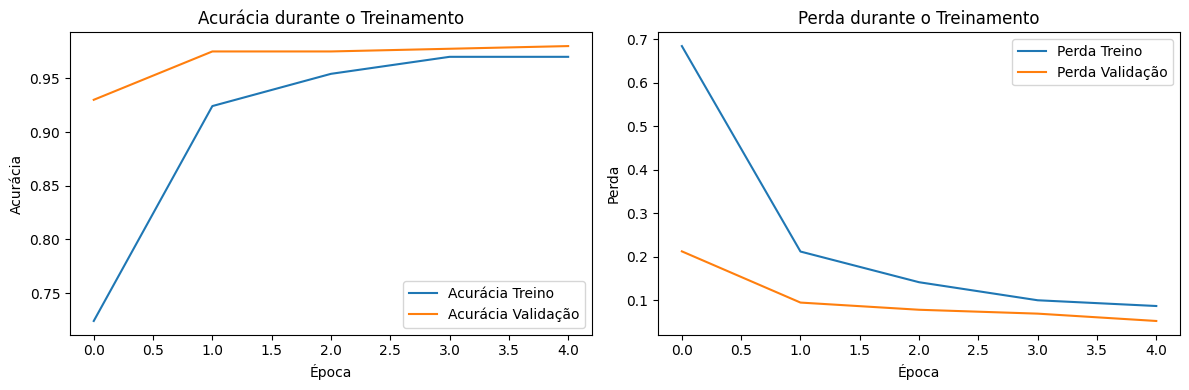

In [29]:
# Plotar curvas de acurácia e perda
plt.figure(figsize=(12, 4))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(history_densenet.history['accuracy'], label='Acurácia Treino')
plt.plot(history_densenet.history['val_accuracy'], label='Acurácia Validação')
plt.title('Acurácia durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Perda
plt.subplot(1, 2, 2)
plt.plot(history_densenet.history['loss'], label='Perda Treino')
plt.plot(history_densenet.history['val_loss'], label='Perda Validação')
plt.title('Perda durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

plt.tight_layout()
plt.show()

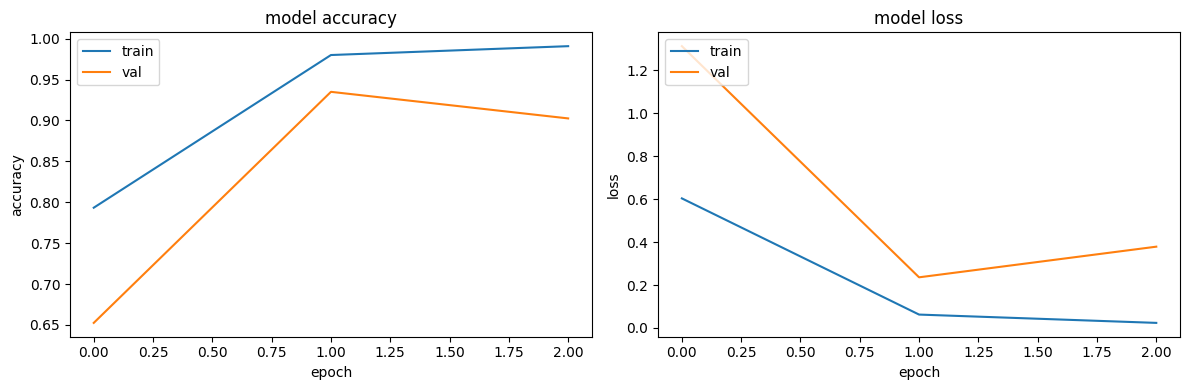

In [31]:
# Plotar curvas de acurácia e perda
plt.figure(figsize=(12, 4))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

# Perda
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# 💡 Conclusão

Tanto o modelo **DenseNet121** como o **Xception** apresentaram bos resultados!

O modelo **DenseNet121** é baseado em *Convoluções Densas*, enquanto **Xception** é baseado em *Convoluções Separáveis*, porém ambos trabalham bem com poucos parâmetros e alta eficiência, sendo apresentados como excelentes opções para desafios como este de separação de imagens por classes (*cluster*).

A acurácia do **DenseNet121** ficou em **0.9800**, em maior que do **Xception** que ficou em **0.9025**, além de apresentar uma perda menor, **0.0528** contra **0.3784**, demonstrando a superioridade do **DenseNet**.

Analisando os gráficos de acurácia (*accuracy*), ambos modelos apresentaram as curvas de acurácia relativamente próximas, com pequenas diferenças, o que é normal em poucas épocas. Isso indica que os modelos aprenderam bem o padrão dos dados sem *overfitting*, ou seja, boa generalização.

Sobre os gráficos de perda (*loss*), verificamos que observamos que tanto o treino (*train*) quanto a validação (*val*) foram diminuindo conforme as épocas evoluíam, indicando que os modelos aprenderam de forma estável. A perda de validação é consistentemente menor que a de treino (o que é até comum, dependendo de técnicas como regularização ou dropout no treino). 

